In [4]:
import plotly.graph_objects as go
import seaborn as sns
import pandas as pd

# Se extraen los datos del dataset penguins

penguins = sns.load_dataset("penguins").dropna()

# Se convierten las columnas cualitativas en cuantitativas

num_island = {'Biscoe': 0, 'Dream': 1, 'Torgersen': 2 }
penguins["num_island"] = penguins["island"].map(num_island)

num_species = {'Adelie': 0, 'Gentoo': 1, 'Chinstrap': 2 }
penguins["num_species"] = penguins["species"].map(num_species)

# Se definen las dimensiones, modificando la de isla para que en el gráfico se muestren los valores como texto 
# y no como categorías numéricas

dimensiones = [
    dict(
        label = "Isla",
        values = penguins["num_island"],
        tickvals = [0, 1, 2],
        ticktext = ['Biscoe', 'Dream', 'Torgersen']
    ),
    dict(label = "Longitud pico (mm)", values = penguins["bill_length_mm"]),
    dict(label = "Profundidad pico (mm)", values = penguins["bill_depth_mm"]),
    dict(label = "Longitud aleta (mm)", values = penguins["flipper_length_mm"]),
    dict(label = "Masa corporal (g)", values = penguins["body_mass_g"])
]

In [5]:

# Se crea la figura utilizando la dimensión de especies para definir el color

fig = go.Figure(data=[
    go.Parcoords(
        line = dict(
            color = penguins["num_species"],
            colorscale = [[0, 'red'], [0.5, 'green'], [1, 'blue']],
            cmin = 0,
            cmax = 2,
            showscale = False
        ),
    dimensions = dimensiones
    )
]
)

# Se crea una leyenda

colors = ['red', 'green', 'blue']
species_names = ['Adelie', 'Gentoo', 'Chinstrap']

for i, color in enumerate(colors):
    fig.add_trace(
        go.Scatter(
            x= [None], y = [None],
            mode = 'markers',
            marker = dict(size = 10, color = color),
            legendgroup = 'species',
            showlegend = True,
            name = species_names[i]

        )
    )

fig.update_layout(title = dict(text="Parallel coordinator pingüinos", x = 0.5, xanchor = 'center', y = 0.95, yanchor = 'top'))

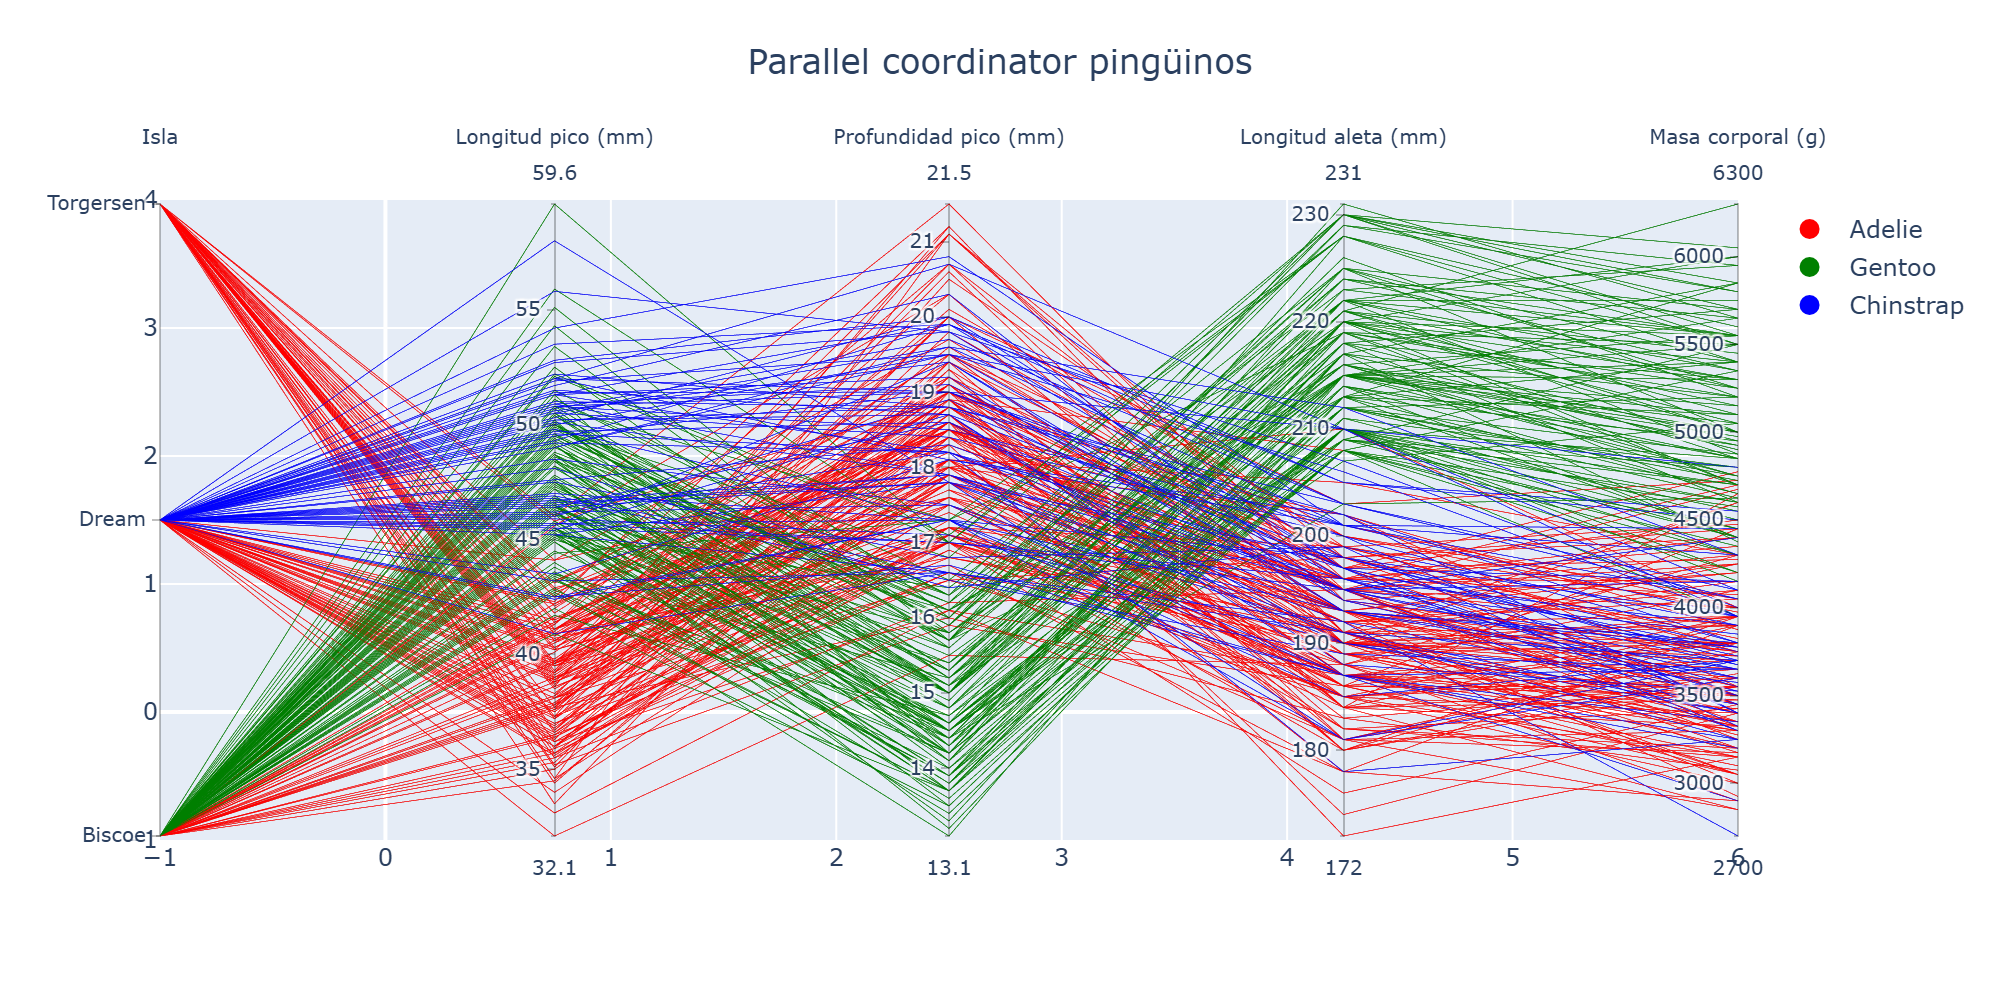

In [6]:
from IPython.display import Image

# Ya que plotly no muestra automáticamente el resultado de ejecución en GitHub, se guarda la figura en una imagen y se muestra

fig.write_image("Parallel_coordinate.png", width=1000, height=500, scale=2)
Image("Parallel_coordinate.png")